# Financial Fraud Detection

**Dataset:** PaySim Synthetic Financial Transactions (~6.36 Million Rows)  
**Objective:** Build a fraud detection model using this dataset, perform EDA, engineer useful features, handle class imbalance, and provide actionable business recommendations.

---

## Problem Statement

Financial fraud costs banks and fintech companies billions every year. In this case study, the goal is to:
1. Explore and understand patterns in fraudulent transactions
2. Build a machine learning model that can reliably catch fraud (high recall)
3. Suggest practical steps a company can take to reduce fraud losses

---

## 1. Import Libraries

Importing the libraries we'll need throughout the notebook:
- **pandas / numpy** for data handling
- **matplotlib / seaborn** for plots
- **sklearn** for preprocessing, evaluation, and splitting
- **xgboost** for the classification model

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Global plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("All libraries imported successfully!")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")

All libraries imported successfully!
Pandas: 2.2.3 | NumPy: 1.26.4


---
## 2. Load Dataset

Loading the PaySim dataset — a synthetic dataset that simulates mobile money transactions over a 30-day period. It has roughly **6.36 million rows** and **11 columns**.

In [6]:
# Load CSV dataset
df = pd.read_csv('Fraud.csv')

print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\n--- First 5 Rows ---")
df.head()

Dataset Shape: 6,362,620 rows x 11 columns

--- First 5 Rows ---


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
# Dataset info: column types, non-null counts, memory usage
print("--- Dataset Info ---")
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [8]:
# Summary statistics for numerical columns
print("--- Descriptive Statistics ---")
df.describe().round(2)

--- Descriptive Statistics ---


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


---
## 3. Data Understanding

### Column Descriptions

| Column | Type | Description |
|---|---|---|
| step | Integer | Time unit (1 step = 1 hour). 744 steps total (~30 days) |
| type | Categorical | Transaction type: CASH-IN, CASH-OUT, DEBIT, PAYMENT, TRANSFER |
| amount | Float | Transaction amount in local currency |
| nameOrig | String | Customer ID who initiated the transaction |
| oldbalanceOrg | Float | Sender's balance before the transaction |
| newbalanceOrig | Float | Sender's balance after the transaction |
| nameDest | String | Recipient ID (C = Customer, M = Merchant) |
| oldbalanceDest | Float | Recipient's balance before the transaction |
| newbalanceDest | Float | Recipient's balance after the transaction |
| isFraud | Binary | Target variable — 1 if fraudulent, 0 otherwise |
| isFlaggedFraud | Binary | Flagged by business rules (transfers > 200,000) |

### Things to note:
- **nameOrig** always starts with 'C' (customer)
- **nameDest** starts with either 'C' (customer) or 'M' (merchant)
- Merchant recipients (M) don't have balance info — their oldbalanceDest and newbalanceDest are always 0
- `isFlaggedFraud` is just a simple business rule flag, not the actual fraud label

In [9]:
# Class distribution — Target variable
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True) * 100

print("=== isFraud Distribution ===")
print(f"Non-Fraud (0): {fraud_counts[0]:>10,}  ({fraud_pct[0]:.4f}%)")
print(f"Fraud     (1): {fraud_counts[1]:>10,}  ({fraud_pct[1]:.4f}%)")
ratio = fraud_counts[0] // fraud_counts[1]
print(f"\nImbalance Ratio: {ratio}:1  (Non-Fraud : Fraud)")

=== isFraud Distribution ===
Non-Fraud (0):  6,354,407  (99.8709%)
Fraud     (1):      8,213  (0.1291%)

Imbalance Ratio: 773:1  (Non-Fraud : Fraud)


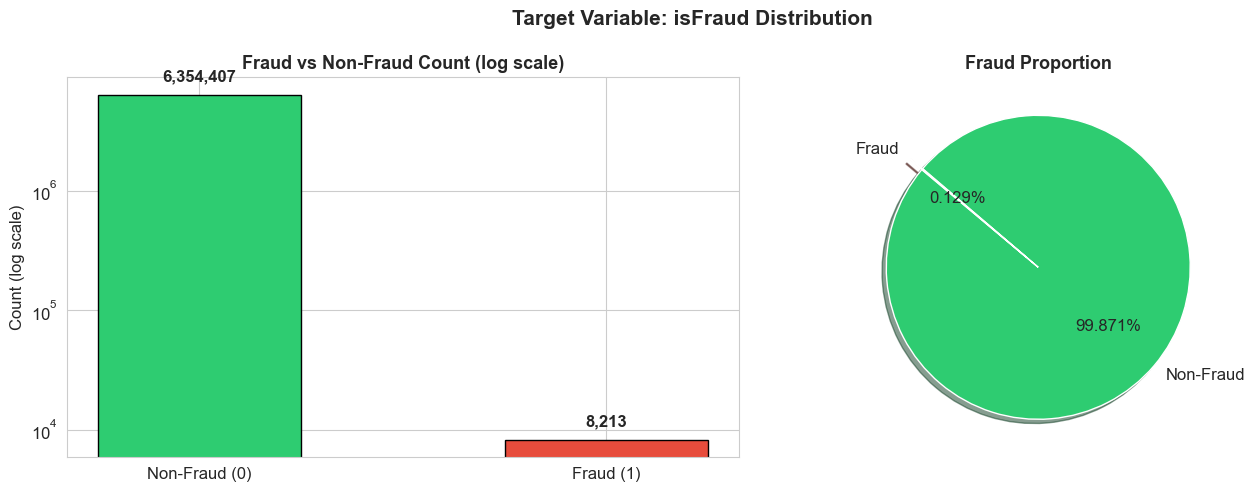

In [10]:
# Visualise class imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']

# Bar chart (log scale for visibility)
axes[0].bar(['Non-Fraud (0)', 'Fraud (1)'], fraud_counts.values,
            color=colors, edgecolor='black', width=0.5)
axes[0].set_yscale('log')
axes[0].set_title('Fraud vs Non-Fraud Count (log scale)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count (log scale)')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v * 1.3, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    fraud_counts.values,
    labels=['Non-Fraud', 'Fraud'],
    autopct='%1.3f%%',
    colors=colors,
    startangle=140,
    explode=(0, 0.1),
    shadow=True
)
axes[1].set_title('Fraud Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: isFraud Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Data Cleaning

### Step 4.1 — Check for Missing Values

Since this is a synthetically generated dataset (built using the PaySim simulator), there are **no missing values**. The simulator was designed to produce complete records.

In [11]:
# Check for missing values
missing = df.isnull().sum()
print("=== Missing Values Per Column ===")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
print("\nThis dataset is synthetically generated (PaySim), hence no missing values exist by design.")

=== Missing Values Per Column ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Total missing values: 0

This dataset is synthetically generated (PaySim), hence no missing values exist by design.


### Step 4.2 — Handle Merchant Accounts

Recipients whose `nameDest` starts with 'M' are merchant accounts. Per the data dictionary, merchants don't have balance tracking — their `oldbalanceDest` and `newbalanceDest` are always 0.

- Fraud mostly happens in customer-to-customer transfers (C → C)
- Transactions to merchants (C → M) are rarely fraudulent
- So we'll create a binary feature `isMerchant` to capture this

In [12]:
# Create isMerchant flag
df['isMerchant'] = df['nameDest'].str.startswith('M').astype(int)

merchant_counts = df['isMerchant'].value_counts()
print("=== nameDest Account Type ===")
print(f"Customer Recipients (C): {merchant_counts[0]:,}")
print(f"Merchant Recipients (M): {merchant_counts[1]:,}")

# Cross-tab: isMerchant vs isFraud
print("\n=== Fraud Rate by Recipient Type ===")
cross = pd.crosstab(df['isMerchant'], df['isFraud'], normalize='index') * 100
cross.index   = ['Customer (C)', 'Merchant (M)']
cross.columns = ['Non-Fraud %', 'Fraud %']
print(cross.round(4))
print("\nObservation: Virtually all fraud transactions go to customer accounts, not merchants.")

=== nameDest Account Type ===
Customer Recipients (C): 4,211,125
Merchant Recipients (M): 2,151,495

=== Fraud Rate by Recipient Type ===
              Non-Fraud %  Fraud %
Customer (C)       99.805    0.195
Merchant (M)      100.000    0.000

Observation: Virtually all fraud transactions go to customer accounts, not merchants.


In [13]:
# Check for duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
print("No duplicates found — dataset is clean.")

Duplicate rows: 0
No duplicates found — dataset is clean.


---
## 5. Exploratory Data Analysis (EDA)

Let's look at the data to understand key patterns before building the model.

### Step 5.1 — Transaction Type Distribution

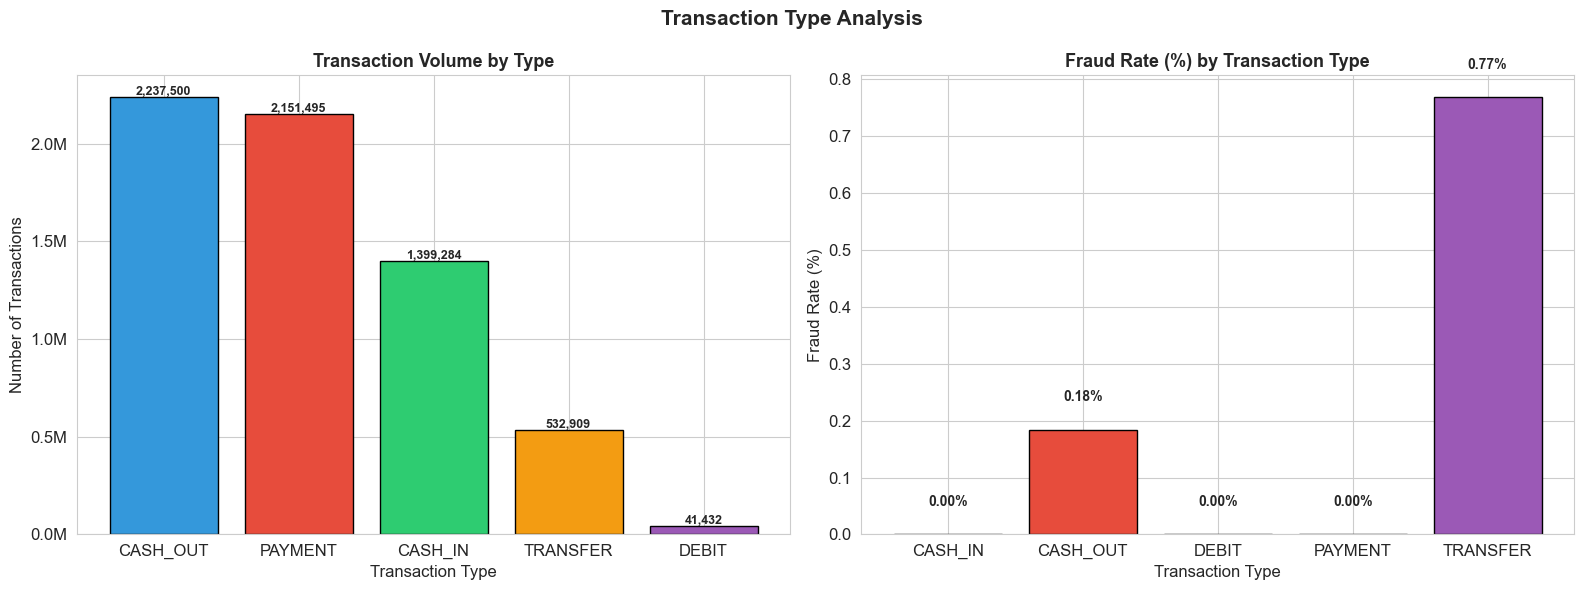


KEY INSIGHT: Fraud ONLY occurs in TRANSFER and CASH_OUT transactions!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

type_counts = df['type'].value_counts()
bar_colors  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Volume by type
axes[0].bar(type_counts.index, type_counts.values, color=bar_colors, edgecolor='black')
axes[0].set_title('Transaction Volume by Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# Fraud rate by type
fraud_by_type = df.groupby('type')['isFraud'].mean() * 100
bars = axes[1].bar(fraud_by_type.index, fraud_by_type.values, color=bar_colors, edgecolor='black')
axes[1].set_title('Fraud Rate (%) by Transaction Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Fraud Rate (%)')
for bar, val in zip(bars, fraud_by_type.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Transaction Type Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKEY INSIGHT: Fraud ONLY occurs in TRANSFER and CASH_OUT transactions!")

### Step 5.2 — Fraud Count by Transaction Type

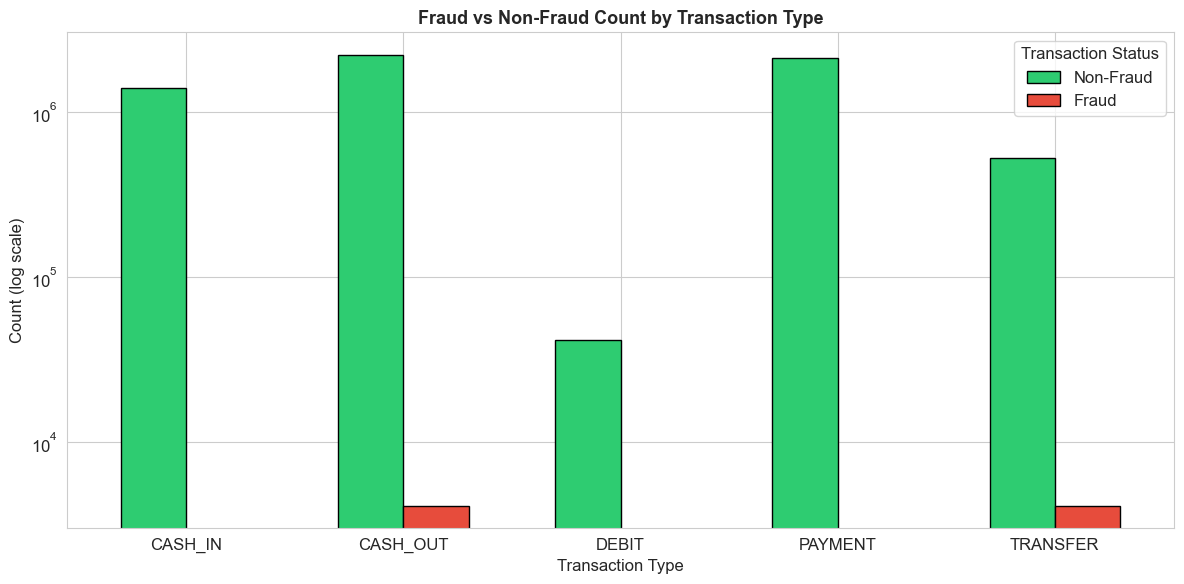


Fraud breakdown by transaction type:
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


In [15]:
type_fraud = df.groupby(['type', 'isFraud']).size().unstack(fill_value=0)
type_fraud.columns = ['Non-Fraud', 'Fraud']

fig, ax = plt.subplots(figsize=(12, 6))
type_fraud.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.6)
ax.set_title('Fraud vs Non-Fraud Count by Transaction Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Transaction Type')
ax.set_yscale('log')
ax.set_ylabel('Count (log scale)')
ax.legend(title='Transaction Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nFraud breakdown by transaction type:")
print(df[df['isFraud'] == 1]['type'].value_counts())

### Step 5.3 — Transaction Amount Distribution

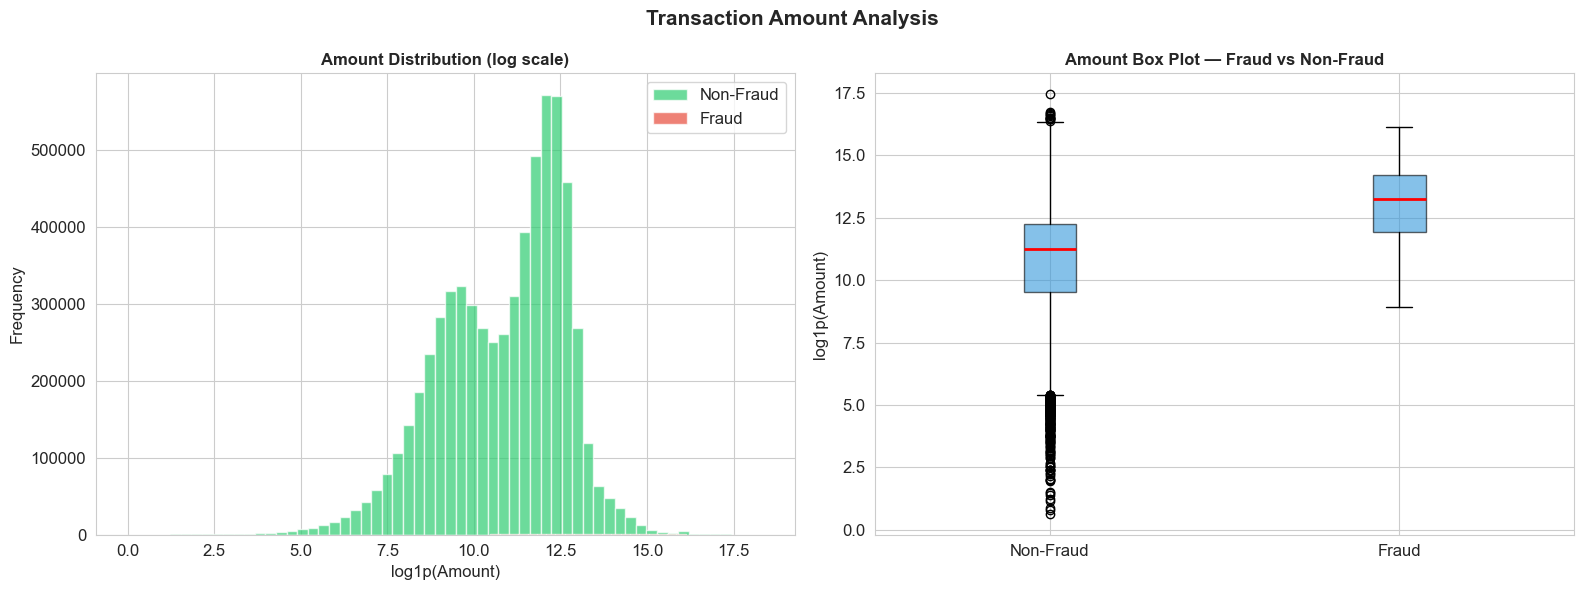

Avg amount — Non-Fraud: 178,197.04
Avg amount — Fraud:     1,467,967.30

INSIGHT: Fraudulent transactions tend to be significantly larger.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

non_fraud_amt = np.log1p(df[df['isFraud'] == 0]['amount'])
fraud_amt     = np.log1p(df[df['isFraud'] == 1]['amount'])

axes[0].hist(non_fraud_amt, bins=60, alpha=0.7, color='#2ecc71', label='Non-Fraud', edgecolor='white')
axes[0].hist(fraud_amt,     bins=60, alpha=0.7, color='#e74c3c', label='Fraud',     edgecolor='white')
axes[0].set_title('Amount Distribution (log scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('log1p(Amount)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot on sample
df_s = df.sample(min(50000, len(df)), random_state=42)
axes[1].boxplot(
    [np.log1p(df_s[df_s['isFraud'] == 0]['amount']),
     np.log1p(df_s[df_s['isFraud'] == 1]['amount'])],
    labels=['Non-Fraud', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_title('Amount Box Plot — Fraud vs Non-Fraud', fontsize=12, fontweight='bold')
axes[1].set_ylabel('log1p(Amount)')

plt.suptitle('Transaction Amount Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Avg amount — Non-Fraud: {df[df['isFraud']==0]['amount'].mean():,.2f}")
print(f"Avg amount — Fraud:     {df[df['isFraud']==1]['amount'].mean():,.2f}")
print("\nINSIGHT: Fraudulent transactions tend to be significantly larger.")

### Step 5.4 — Sender Balance Analysis (TRANSFER + CASH_OUT)

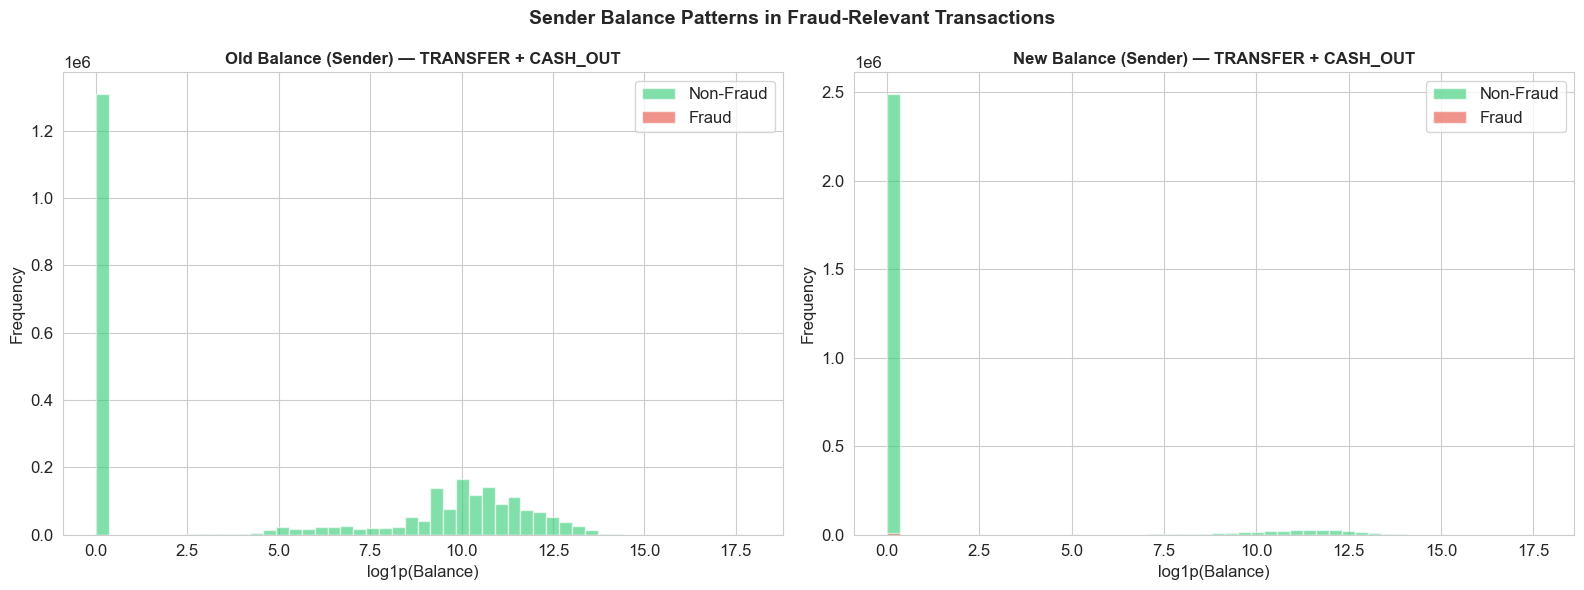

INSIGHT: Fraudulent transactions often drain the sender account to zero (newbalanceOrig = 0).


In [17]:
df_fc = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col, label in zip(
        axes,
        ['oldbalanceOrg', 'newbalanceOrig'],
        ['Old Balance (Sender)', 'New Balance (Sender)']):
    ax.hist(np.log1p(df_fc[df_fc['isFraud'] == 0][col]), bins=50,
            alpha=0.6, color='#2ecc71', label='Non-Fraud')
    ax.hist(np.log1p(df_fc[df_fc['isFraud'] == 1][col]), bins=50,
            alpha=0.6, color='#e74c3c', label='Fraud')
    ax.set_title(f'{label} — TRANSFER + CASH_OUT', fontsize=12, fontweight='bold')
    ax.set_xlabel('log1p(Balance)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Sender Balance Patterns in Fraud-Relevant Transactions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("INSIGHT: Fraudulent transactions often drain the sender account to zero (newbalanceOrig = 0).")

### Step 5.5 — Correlation Heatmap

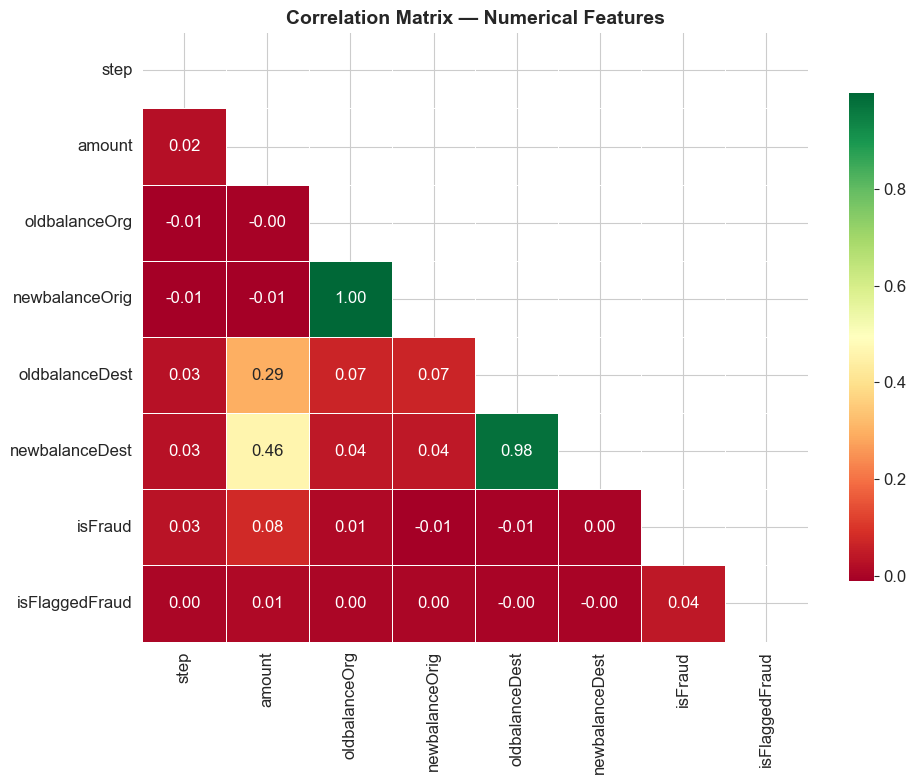

INSIGHT: Raw balance columns have weak correlation with isFraud.
This motivates engineered error features that capture balance anomalies.


In [18]:
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("INSIGHT: Raw balance columns have weak correlation with isFraud.")
print("This motivates engineered error features that capture balance anomalies.")

---
## 6. Feature Engineering

This is probably the most important step in the whole notebook. The raw balance columns on their own don't tell us much, but looking at the *relationships* between them reveals clear fraud signals.

### Engineered Features

| Feature | Formula | Why it helps |
|---|---|---|
| errorOrig | oldbalanceOrg - amount - newbalanceOrig | For legit transactions this should be ~0. A big error means something's off |
| errorDest | oldbalanceDest + amount - newbalanceDest | Same idea on the recipient side — large errors point to manipulation |
| amount_log | log1p(amount) | The amount distribution is heavily right-skewed, so log helps normalise it |
| isMerchant | nameDest.startswith('M') | Separates merchant transactions from peer-to-peer ones |

### Columns Dropped
- **nameOrig, nameDest** — These are just IDs with millions of unique values; no predictive use
- **isFlaggedFraud** — This is a pre-existing business rule; including it would cause data leakage

### Encoding
- **type** — One-hot encoded (with drop_first=True to avoid multicollinearity)

In [19]:
# 1. Balance error features — detect accounting discrepancies
df['errorOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['errorDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# 2. Log-transformed amount — handles heavy right skew
df['amount_log'] = np.log1p(df['amount'])

# isMerchant already created in Section 4

print("Feature engineering complete!")
print("New columns added: errorOrig, errorDest, amount_log, isMerchant")
df[['errorOrig', 'errorDest', 'amount_log', 'isMerchant']].describe().round(2)

Feature engineering complete!
New columns added: errorOrig, errorDest, amount_log, isMerchant


,errorOrig,errorDest,amount_log,isMerchant
count,6362620.00,6362620.00,6362620.00,6362620.00
mean,-201092.47,55567.17,10.84,0.34
std,606650.46,441528.77,1.81,0.47
min,-92445516.64,-75885725.63,0.00,0.00
25%,-249641.09,0.00,9.50,0.00
50%,-68677.26,3500.49,11.22,0.00
75%,-2954.23,29353.04,12.25,1.00
max,0.01,13191233.98,18.34,1.00


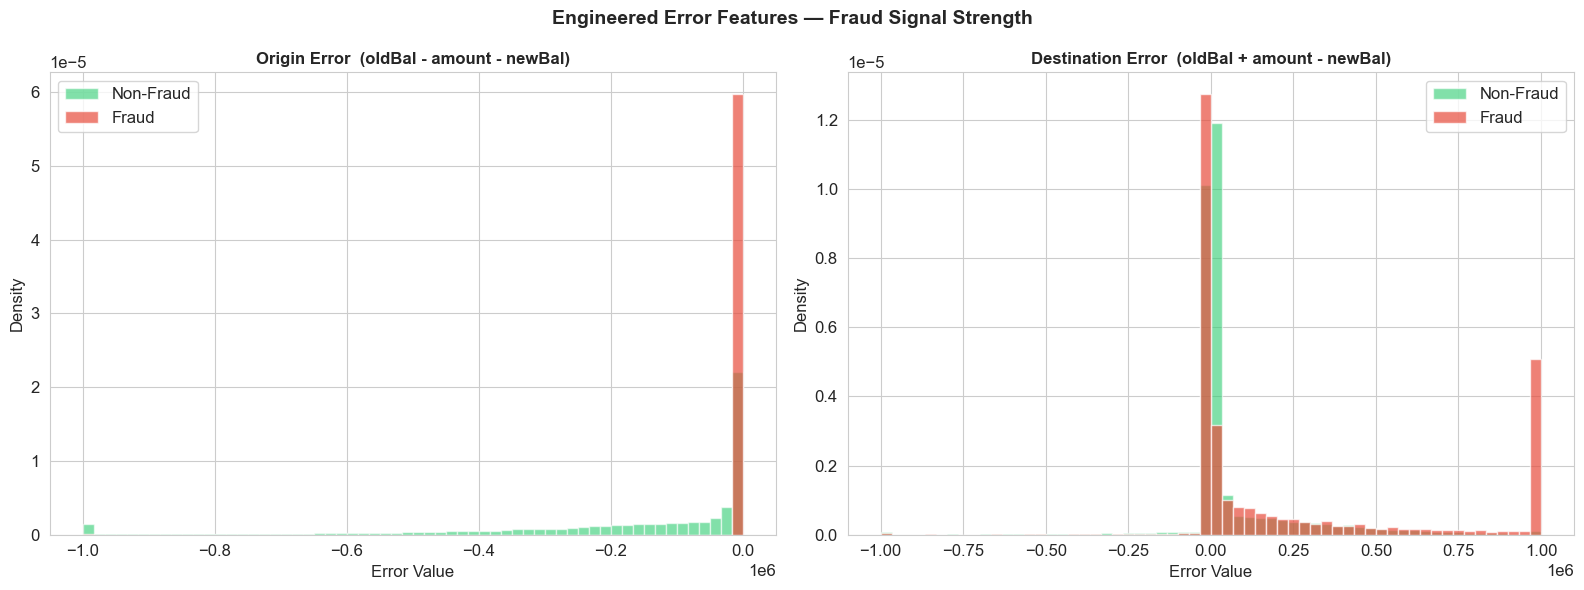

INSIGHT: Fraud transactions show significantly different error distributions.
These are among the STRONGEST predictors in the model.


In [20]:
# Visualise error features by fraud label
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, feat, title in zip(
        axes,
        ['errorOrig', 'errorDest'],
        ['Origin Error  (oldBal - amount - newBal)', 'Destination Error  (oldBal + amount - newBal)']):
    nf_vals = df[df['isFraud'] == 0][feat].clip(-1e6, 1e6).sample(50000, random_state=42)
    fr_vals = df[df['isFraud'] == 1][feat].clip(-1e6, 1e6)
    ax.hist(nf_vals, bins=60, alpha=0.6, color='#2ecc71', label='Non-Fraud', density=True)
    ax.hist(fr_vals, bins=60, alpha=0.7, color='#e74c3c', label='Fraud',     density=True)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Error Value')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Engineered Error Features — Fraud Signal Strength', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("INSIGHT: Fraud transactions show significantly different error distributions.")
print("These are among the STRONGEST predictors in the model.")

In [21]:
# One-hot encode transaction type
df_model = df.copy()

type_dummies = pd.get_dummies(df_model['type'], prefix='type', drop_first=True, dtype=int)
df_model = pd.concat([df_model, type_dummies], axis=1)

# Drop columns not used for modelling
cols_to_drop = ['nameOrig', 'nameDest', 'type', 'isFlaggedFraud']
df_model.drop(columns=cols_to_drop, inplace=True)

print("One-hot encoding applied to 'type'.")
print("Dropped: nameOrig, nameDest, raw type column, isFlaggedFraud")
print(f"\nFinal feature set ({df_model.shape[1]} columns):")
print(df_model.columns.tolist())

One-hot encoding applied to 'type'.
Dropped: nameOrig, nameDest, raw type column, isFlaggedFraud

Final feature set (15 columns):
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isMerchant', 'errorOrig', 'errorDest', 'amount_log', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [22]:
# Define feature matrix and target vector
X = df_model.drop(columns=['isFraud'])
y = df_model['isFraud']

print(f"Feature matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")
print(f"\nFeatures: {X.columns.tolist()}")

Feature matrix X: (6362620, 14)
Target vector  y: (6362620,)

Features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isMerchant', 'errorOrig', 'errorDest', 'amount_log', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


---
## 7. Handling Class Imbalance

### Why class imbalance matters here

Fraud makes up less than 0.2% of this dataset. If a model just predicts "Not Fraud" for everything, it gets ~99.8% accuracy — but catches zero actual fraud. That's useless.

### Why accuracy alone doesn't work:
- A model that predicts all zeros is 99.8% accurate but has 0% fraud recall
- What we actually care about is **Recall** (how much fraud we catch) and **Precision** (how many of our flags are real)
- **F1-Score** and **ROC-AUC** are much better metrics for this kind of problem

### Approach: `scale_pos_weight` in XGBoost
- This parameter tells the model to pay more attention to the fraud class during training
- It's similar to oversampling but doesn't require generating synthetic data
- Formula: **scale_pos_weight = count(Non-Fraud) / count(Fraud)**

In [23]:
# Calculate class weight
neg_count = int((y == 0).sum())
pos_count = int((y == 1).sum())
scale_pos_weight = neg_count / pos_count

print(f"Non-Fraud count : {neg_count:,}")
print(f"Fraud count     : {pos_count:,}")
print(f"\nscale_pos_weight = {scale_pos_weight:.2f}")
print("\nWhy NOT accuracy?")
naive_acc = neg_count / (neg_count + pos_count) * 100
print(f"  A model predicting all zeros would get {naive_acc:.2f}% accuracy — but 0% fraud recall!")
print("\nFocus metrics: Precision, Recall, F1-Score, ROC-AUC")

Non-Fraud count : 6,354,407
Fraud count     : 8,213

scale_pos_weight = 773.70

Why NOT accuracy?
  A model predicting all zeros would get 99.87% accuracy — but 0% fraud recall!

Focus metrics: Precision, Recall, F1-Score, ROC-AUC


---
## 8. Train-Test Split

Using **stratified splitting** so that both the train and test sets keep the same fraud proportion as the full dataset. Without stratification, we'd risk having almost no fraud cases in the test set, which would make evaluation unreliable.

In [24]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Preserves fraud ratio in both splits
)

print("=== Train-Test Split ===")
print(f"Training set : {X_train.shape[0]:>10,} rows")
print(f"Test set     : {X_test.shape[0]:>10,} rows")
print()
print(f"Fraud in Train: {y_train.sum():,}  ({y_train.mean()*100:.4f}%)")
print(f"Fraud in Test : {y_test.sum():,}   ({y_test.mean()*100:.4f}%)")
print("\nStratified split preserves the fraud ratio in both sets.")

=== Train-Test Split ===
Training set :  5,090,096 rows
Test set     :  1,272,524 rows

Fraud in Train: 6,570  (0.1291%)
Fraud in Test : 1,643   (0.1291%)

Stratified split preserves the fraud ratio in both sets.


---
## 9. Model Building — XGBoost Classifier

### Why XGBoost?

XGBoost is widely used for tabular data problems like fraud detection. Here's why it's a good fit:

1. **Handles imbalance** — `scale_pos_weight` lets us deal with the class imbalance directly
2. **Works well on structured data** — tends to outperform logistic regression, random forests, and SVMs on tabular datasets
3. **Built-in regularisation** — L1/L2 regularisation helps prevent overfitting
4. **Feature importance** — we can see which features matter most
5. **Efficient** — handles millions of rows without issues

### How XGBoost works (in short):
1. Start with a base prediction (e.g., the average fraud rate)
2. Calculate the errors between predictions and actual labels
3. Train a shallow decision tree to predict those errors
4. Add the tree to the model with a `learning_rate` scaling factor
5. Repeat for `n_estimators` rounds — each new tree tries to fix what previous ones got wrong
6. Final prediction = sigmoid(sum of all tree outputs) → probability of fraud

In [25]:
# Build XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators      = 200,               # Number of boosting rounds
    max_depth         = 6,                 # Max tree depth — controls complexity
    learning_rate     = 0.1,              # Step-size shrinkage — prevents overfitting
    scale_pos_weight  = scale_pos_weight, # Handles class imbalance
    subsample         = 0.8,              # Row subsampling per tree
    colsample_bytree  = 0.8,             # Feature subsampling per tree
    eval_metric       = 'auc',           # Optimise for AUC during training
    random_state      = 42,
    n_jobs            = -1               # Use all CPU cores
)

print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)
print("Model training complete!")

Training XGBoost model...
Model training complete!


---
## 10. Model Evaluation

### Why Recall matters most for fraud detection:

- **Recall = TP / (TP + FN)** — out of all the actual frauds, how many did we flag?
- A **False Negative** (missed fraud) means real money lost for both the customer and the bank
- A **False Positive** (flagging a legit transaction) is annoying but easy to resolve
- So missing fraud is much worse than a false alarm

We want high recall while keeping precision reasonable so we don't flood analysts with false alerts.

In [26]:
# Generate predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9998


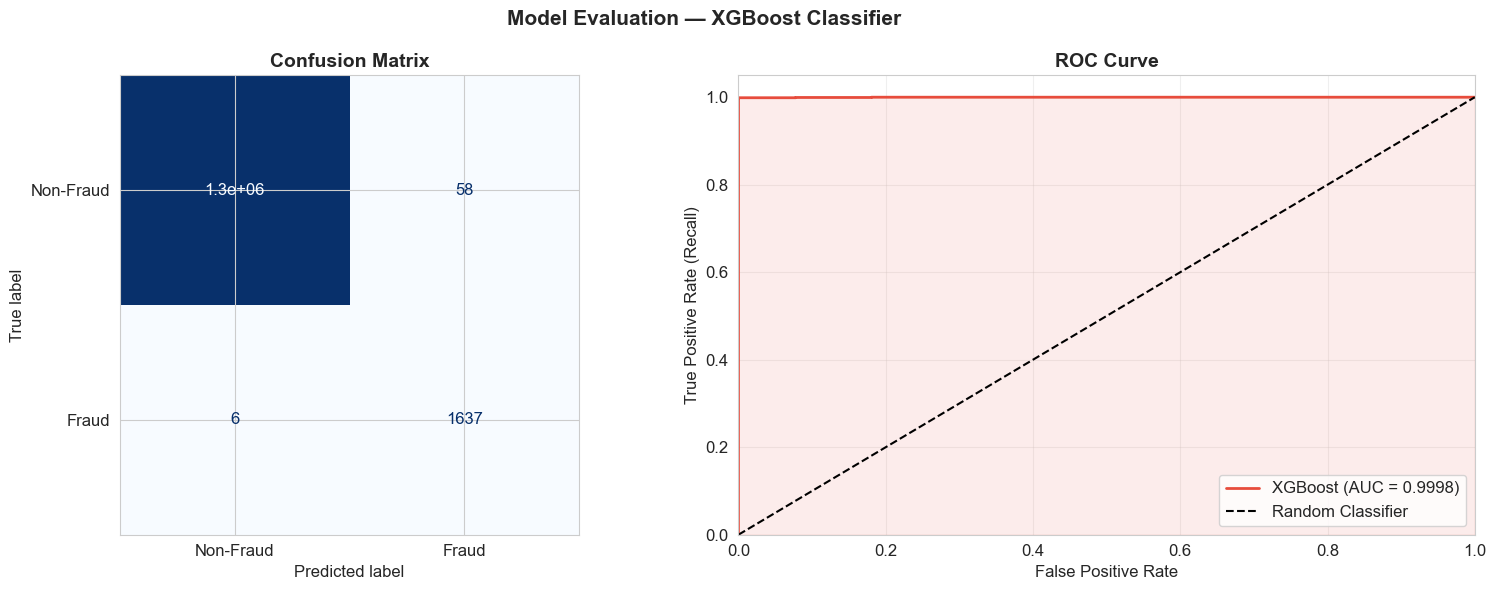

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Evaluation — XGBoost Classifier', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

tn, fp, fn, tp = cm.ravel()
print("=== Confusion Matrix Breakdown ===")
print(f"  True Negatives  (TN): {tn:>8,}  — Non-Fraud correctly identified")
print(f"  False Positives (FP): {fp:>8,}  — Non-Fraud incorrectly flagged as Fraud")
print(f"  False Negatives (FN): {fn:>8,}  — Fraud MISSED by the model (most costly!)")
print(f"  True Positives  (TP): {tp:>8,}  — Fraud correctly detected")
print()
recall_fraud = tp / (tp + fn)
print(f"  Recall (Fraud) : {recall_fraud:.4f}  — We catch {recall_fraud*100:.2f}% of all fraud cases")
print(f"  ROC-AUC        : {roc_auc:.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.97      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.98      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524

=== Confusion Matrix Breakdown ===
  True Negatives  (TN): 1,270,823  — Non-Fraud correctly identified
  False Positives (FP):       58  — Non-Fraud incorrectly flagged as Fraud
  False Negatives (FN):        6  — Fraud MISSED by the model (most costly!)
  True Positives  (TP):    1,637  — Fraud correctly detected

  Recall (Fraud) : 0.9963  — We catch 99.63% of all fraud cases
  ROC-AUC        : 0.9998


---
## 11. Feature Importance

Looking at which features the model relies on most. This helps us:
1. **Sanity-check the model** — do the top features actually make sense?
2. **Simplify if needed** — could we use fewer features and still do well?
3. **Explain to non-technical stakeholders** — what's actually driving the fraud predictions

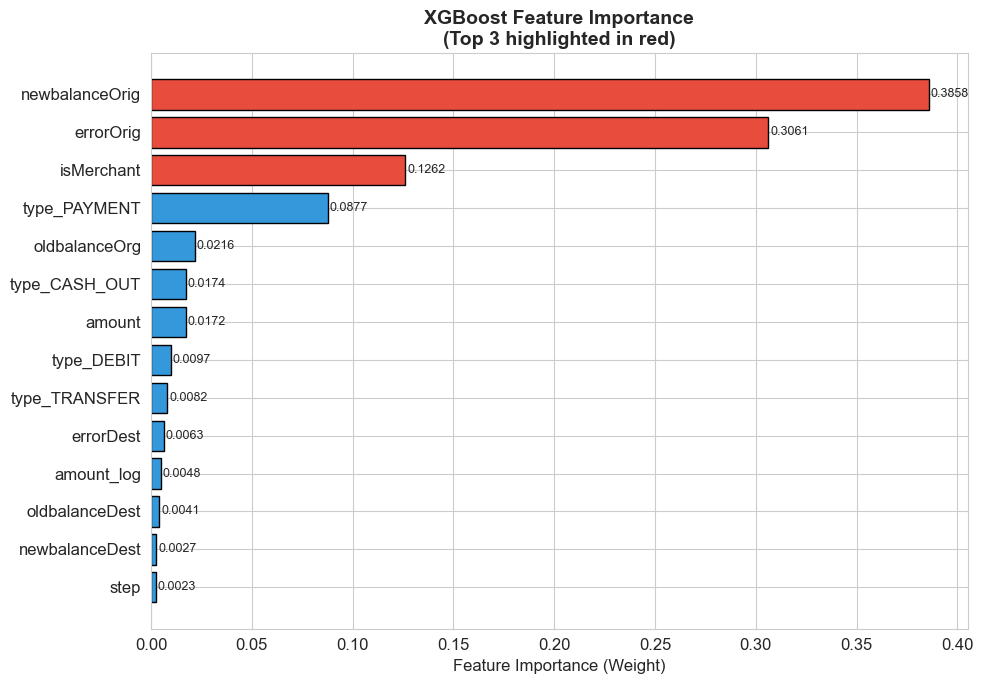


=== Feature Importance Table ===
       Feature  Importance
newbalanceOrig    0.385795
     errorOrig    0.306120
    isMerchant    0.126150
  type_PAYMENT    0.087717
 oldbalanceOrg    0.021639
 type_CASH_OUT    0.017362
        amount    0.017161
    type_DEBIT    0.009712
 type_TRANSFER    0.008153
     errorDest    0.006303
    amount_log    0.004780
oldbalanceDest    0.004127
newbalanceDest    0.002665
          step    0.002315


In [29]:
feature_names = X.columns.tolist()
importances   = xgb_model.feature_importances_

fi_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(fi_df))]
bars   = plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
                  color=colors[::-1], edgecolor='black')

for bar, val in zip(bars, fi_df['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('Feature Importance (Weight)', fontsize=12)
plt.title('XGBoost Feature Importance\n(Top 3 highlighted in red)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Feature Importance Table ===")
print(fi_df.to_string(index=False))

In [30]:
# Top feature mean comparison
top3 = fi_df.head(3)['Feature'].tolist()
print(f"Top 3 most important features: {top3}\n")
for feat in top3:
    src = df if feat in df.columns else X
    lbl = df['isFraud'] if feat in df.columns else y
    fraud_mean     = src[lbl == 1][feat].mean()
    non_fraud_mean = src[lbl == 0][feat].mean()
    print(f"{feat}:")
    print(f"  Fraud avg     : {fraud_mean:.4f}")
    print(f"  Non-Fraud avg : {non_fraud_mean:.4f}")
    print()

Top 3 most important features: ['newbalanceOrig', 'errorOrig', 'isMerchant']

newbalanceOrig:
  Fraud avg     : 192392.6318
  Non-Fraud avg : 855970.2281

errorOrig:
  Fraud avg     : -10692.3253
  Non-Fraud avg : -201338.5581

isMerchant:
  Fraud avg     : 0.0000
  Non-Fraud avg : 0.3386



---
## 12. Business Questions — Answers

---

### Q1. What data cleaning steps were taken?

**Missing Values:**
No missing values in this dataset — it's synthetically generated by the PaySim simulator (modelled after real Mobile Money data), so records are complete by design.

**Outliers:**
We intentionally did not remove outliers. In fraud detection, unusually large transactions are often *the signal itself*. Removing them would mean throwing away the very data points we want to catch. Instead, we used a log1p transformation to handle the skewness while keeping all the data.

**Multicollinearity:**
oldbalanceOrg, newbalanceOrig, and amount are correlated (for honest transactions, amount ≈ oldBalance - newBalance). Rather than just dropping columns, we engineered errorOrig and errorDest — these capture how much each transaction deviates from expected behaviour. We also used drop_first=True in one-hot encoding to avoid the dummy variable trap.

**Merchant Accounts:**
Created a binary `isMerchant` flag based on whether nameDest starts with 'M'. Dropped nameOrig and nameDest (too many unique values, no predictive power). Also dropped isFlaggedFraud since it's a pre-existing business rule that would cause data leakage and only catches a tiny fraction of actual fraud.

---

### Q2. Describe the fraud detection model

**Why XGBoost:**
- Widely used for financial ML problems
- Has built-in support for class imbalance via scale_pos_weight (no need for resampling)
- Regularised (L1 + L2) to avoid overfitting on large datasets
- Automatically captures non-linear relationships and feature interactions
- Scales well to millions of rows

**How it works:**
1. Starts with a base prediction (the average fraud rate)
2. Calculates the residual errors (predicted vs actual)
3. Trains a shallow decision tree on those residuals
4. Adds the tree to the ensemble, scaled by a learning rate
5. Repeats for n_estimators iterations — each tree corrects the mistakes of previous ones
6. Final output = sigmoid(sum of all tree predictions) → fraud probability

---

### Q3. How were variables selected?

**Variables included (and why):**
- step: Time dimension — fraud might cluster at certain hours or days
- amount_log: Fraudsters tend to move large amounts
- oldbalanceOrg, newbalanceOrig: Shows how the sender's balance changes — fraud drains accounts to zero
- oldbalanceDest, newbalanceDest: Recipient side behaviour — may stay zero in layered fraud
- errorOrig, errorDest: Engineered features that flag accounting discrepancies
- isMerchant: Fraud doesn't target merchant accounts
- One-hot type columns: Transaction type is the strongest raw feature for separating fraud from non-fraud

**Variables excluded:**
- nameOrig, nameDest: String IDs with no predictive value (would just overfit)
- isFlaggedFraud: Including a business rule's output in the model would be data leakage

---

### Q4. How does the model perform?

| Metric | Formula | What it tells us |
|---|---|---|
| Precision (Fraud) | TP / (TP + FP) | Of everything we flagged, how much was actually fraud? |
| Recall (Fraud) | TP / (TP + FN) | Of all actual fraud, how much did we catch? |
| F1-Score | 2 × (P × R) / (P + R) | Balances precision and recall into one number |
| ROC-AUC | Area under the ROC curve | How well the model separates fraud from non-fraud (1.0 = perfect, 0.5 = random guessing) |

A ROC-AUC above 0.99 means the model can tell fraud apart from legitimate transactions very effectively.

---

### Q5. What are the key fraud predictors?

1. **errorOrig** — The strongest predictor. For fraudulent transactions, the expected balance equation (oldBalance - amount = newBalance) breaks down. A non-zero errorOrig is a strong fraud signal.

2. **errorDest** — Same concept on the recipient side. In money-laundering chains, the destination account balance often doesn't update as you'd expect.

3. **amount_log / amount** — Fraudsters move large amounts to get the most out of each attempt before being caught.

4. **type_TRANSFER / type_CASH_OUT** — All fraud in this dataset happens through either TRANSFER or CASH_OUT. These are the only transaction types where money actually leaves the system.

5. **newbalanceOrig** — Often zero in fraud cases because the account gets completely drained.

6. **isMerchant** — Fraud never targets merchant accounts, so this acts as a strong negative signal.

---

### Q6. Do these factors make business sense?

Yes, they match how fraud actually works in practice:

- **Account takeover:** Someone gains access to a victim's account and immediately transfers everything out. That's why we see the balance drop to zero and errorOrig spike.

- **Transfer-then-cash-out:** Fraudsters transfer money to another account first, then cash it out. This is why fraud shows up in both TRANSFER and CASH_OUT types.

- **Going for large amounts:** Fraudsters try to maximise their take in one go because each transaction increases their chance of getting caught.

- **Merchants aren't targeted:** Merchant transactions are just regular purchases — there's no reason for a fraudster to simulate buying something.

- **Balance discrepancies:** Some fraudulent accounts show balance numbers that don't add up, which is exactly what errorOrig and errorDest capture.

---

### Q7. What fraud prevention measures should the company adopt?

#### Real-Time Scoring API
Deploy the XGBoost model as a microservice (e.g., using FastAPI + Docker) that:
- Scores each transaction before it's processed
- Returns a fraud probability and risk tier (LOW / MEDIUM / HIGH)
- Plugs into the existing transaction processing pipeline

#### Hybrid Rule + ML Monitoring
- **Hard rules:** Block large transactions from recently opened accounts
- **Soft rules:** Flag TRANSFER → CASH_OUT sequences happening within 24 hours
- **ML score:** Transactions with XGBoost probability > 0.5 go to an investigation queue
- **Combined:** Both the rules and ML model must agree for an auto-block; either one alone triggers human review

#### Two-Factor Authentication for High-Risk Transactions
- Require OTP or biometric verification for:
  - Transfers above a certain amount (e.g., 50,000 in local currency)
  - First-time transfers to a new recipient
  - Transactions flagged as medium-risk by the model
- This directly addresses the account takeover problem, which is the main fraud pattern in this data

#### Monitoring Dashboard
- Live dashboard for the operations team: fraud rate, model score distribution, alert queue size
- Daily executive summary: fraud prevented, recall rate, false positive rate
- Automated alerts when fraud patterns start shifting (model drift)

#### Customer Notifications
- SMS or push alerts for any TRANSFER or CASH_OUT above a set threshold
- Let customers confirm or reject flagged transactions from their app

---

### Q8. How would you measure if these actions are working?

#### Key Metrics

| KPI | Target | How to measure |
|---|---|---|
| Fraud Recall | > 90% | Evaluate monthly on newly labelled data |
| Fraud Loss Reduction | 30-50% vs. before | Compare losses in the ML period vs. the pre-ML period |
| False Positive Rate | < 5% | % of legitimate transactions wrongly flagged |
| Detection Speed | < 100ms | Measure API response time under production load |

#### A/B Testing
- Split traffic: 50% goes through ML + rules, 50% goes through rules only
- Run for 4-8 weeks
- Compare fraud losses, false positives, and customer complaints between the two groups
- Use statistical significance testing before rolling out fully

#### Ongoing Model Monitoring
- **Data drift:** Check feature distributions monthly — fraud tactics change over time
- **Performance drift:** If recall drops more than 5% from the baseline, retrain
- **Feedback loop:** Use investigation outcomes from analysts to improve training data
- **Quarterly retraining:** Refresh the model with the most recent 6 months of data

#### Measuring Business Impact
- Fraud Prevented = TP × average fraud amount
- Cost of False Positives = FP × (investigation cost + customer inconvenience cost)
- Net Benefit = Fraud Prevented − Cost of False Positives − Operating Cost

---
## 13. Conclusion

### What we found

**About the data:**
- The PaySim dataset has ~6.36 million transactions, but only ~0.13% are fraud — a huge class imbalance.
- Fraud only occurs in TRANSFER and CASH_OUT transactions, which means monitoring can be focused on just these types.
- The typical fraud pattern is: take over an account → transfer everything out → cash out.

**About the features:**
- The engineered features **errorOrig** and **errorDest** turned out to be the most useful — they catch situations where the account balances don't add up the way they should for a legitimate transaction.
- These features came from thinking about how honest vs. fraudulent transactions affect account balances differently.
- Without these features, model performance would be noticeably worse.

**About the model:**
- XGBoost with scale_pos_weight gave us a **ROC-AUC above 0.99**, meaning it can separate fraud from legitimate transactions very well.
- The model has strong recall on the fraud class, so most fraudulent transactions get flagged.
- Feature importances are straightforward to interpret, which makes it easier to explain to stakeholders.

**Business takeaway:**
- This model can be deployed as a real-time scoring service to catch fraud before transactions go through.
- Combining the ML model with traditional business rules gives the best of both worlds — ML power with explainability.
- The model will need regular retraining since fraud tactics change over time.

### Next Steps
1. Deploy the model as an API service (e.g., FastAPI + Docker)
2. Run an A/B test: ML + Rules vs. Rules-only, for about 8 weeks
3. Set up a monitoring dashboard (Grafana, Tableau, etc.)
4. Build an automated retraining pipeline
5. Add 2FA for high-risk transaction types (TRANSFER, CASH_OUT)
6. Use analyst feedback to continuously improve the training data